In [1]:
# %pip install numpy
# %pip install pandas
# %pip install seaborn
# %pip install matplotlib

In [2]:
# %pip install sklearn

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('insurance.csv')

# EDA

In [5]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
df.shape

(1338, 7)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [8]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [9]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [10]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

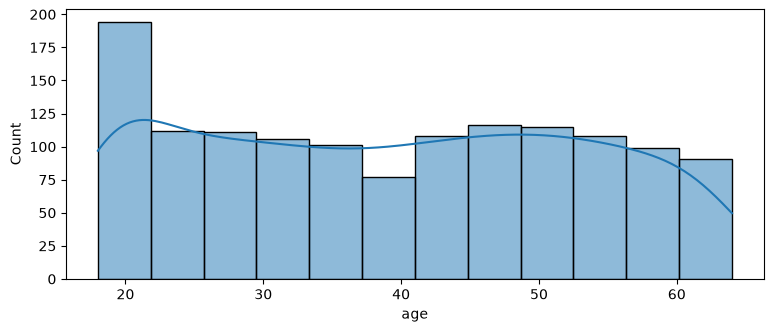

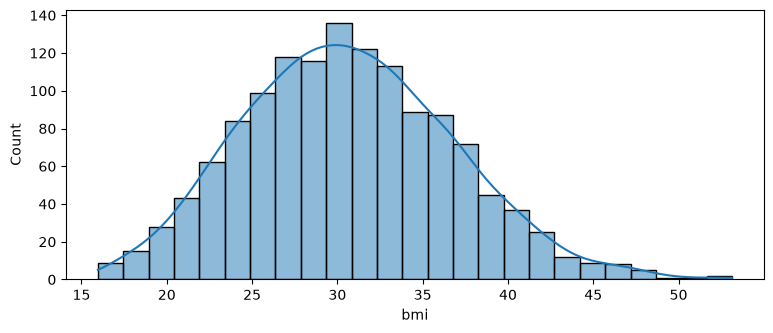

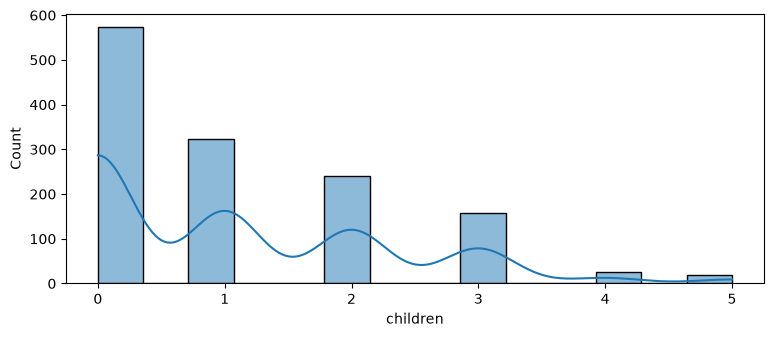

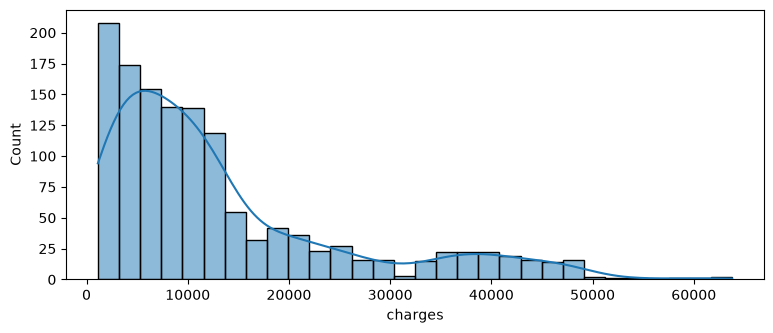

In [11]:
numeric_columns = ['age','bmi','children','charges']
for col in numeric_columns:
    plt.figure(figsize=(9,3.5))
    sns.histplot(df[col], kde=True)

<Axes: xlabel='children', ylabel='count'>

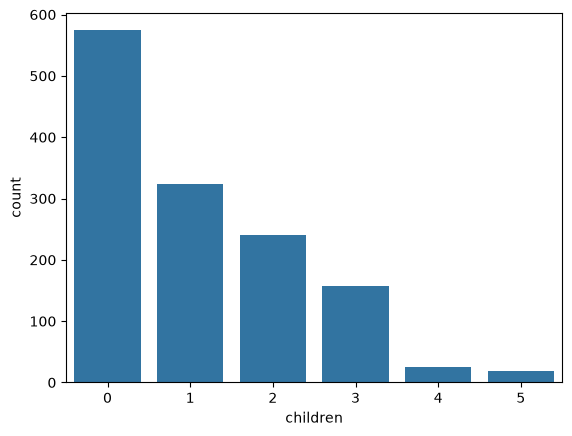

In [12]:
# Count Plot

sns.countplot(x = df['children'])

<Axes: xlabel='sex', ylabel='count'>

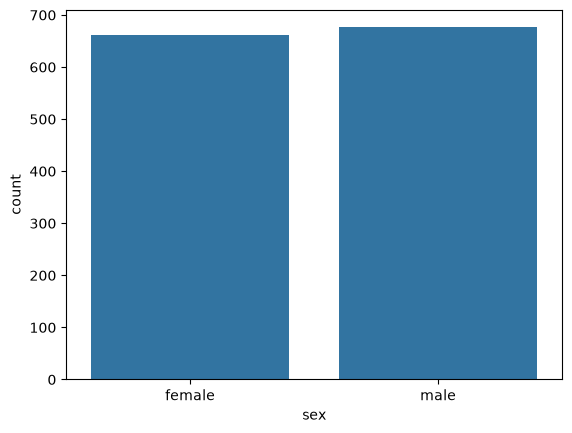

In [13]:
sns.countplot(x = df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

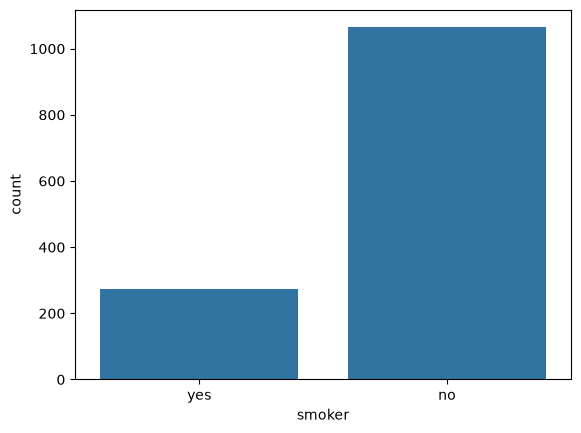

In [14]:
sns.countplot(x = df['smoker'])

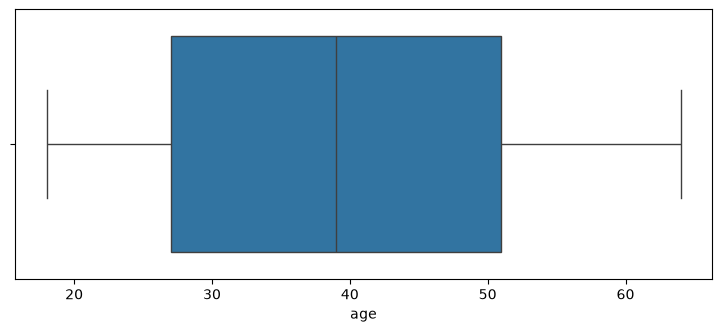

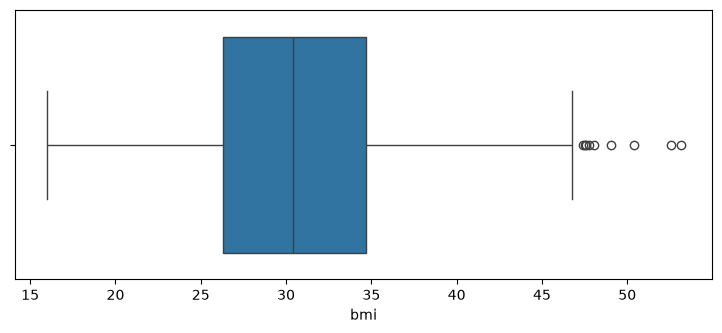

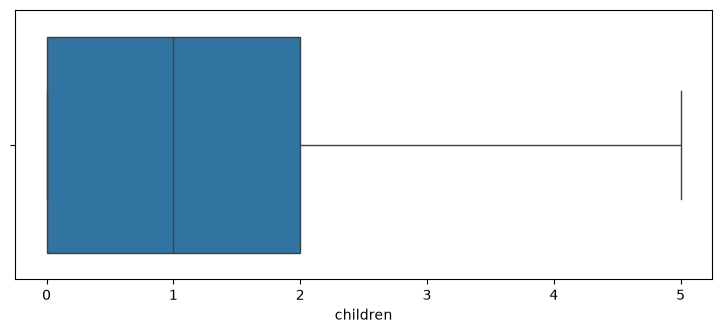

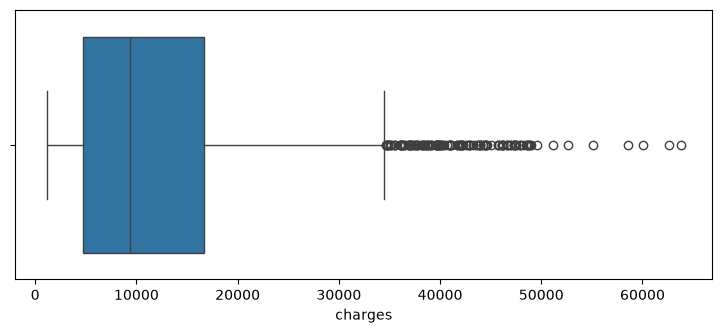

In [15]:
for col in numeric_columns:
    plt.figure(figsize=(9,3.5))
    sns.boxplot(x=df[col])

<Axes: >

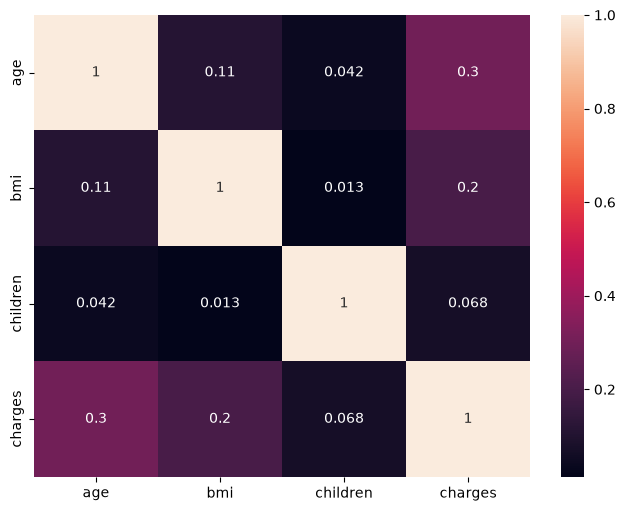

In [16]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)

# Data Cleaning and Preprocessing

In [17]:
df_cleaned = df.copy()

In [18]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [19]:
df.shape

(1338, 7)

In [20]:
df_cleaned.drop_duplicates(inplace=True)

In [21]:
df_cleaned.shape

(1337, 7)

In [22]:
df_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [23]:
df_cleaned.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [24]:
df_cleaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [25]:
df_cleaned['sex'] = df_cleaned['sex'].map({'male':0, 'female':1})

In [26]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [27]:
df_cleaned['smoker'] = df_cleaned['smoker'].map({'no':0, 'yes':1})

In [28]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [29]:
df_cleaned = df_cleaned.rename(columns={
    'sex' : 'isFemale',
    'smoker': 'isSmoker'
})

In [30]:
df_cleaned.head()

,age,isFemale,bmi,children,isSmoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [31]:
df_cleaned['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [32]:
# One Hot Encoding

df_cleaned = pd.get_dummies(df_cleaned,columns = ['region'])

In [33]:
df_cleaned.head()

,age,isFemale,bmi,children,isSmoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,False,True
1,18,0,33.770,1,0,1725.55230,False,False,True,False
2,28,0,33.000,3,0,4449.46200,False,False,True,False
3,33,0,22.705,0,0,21984.47061,False,True,False,False
4,32,0,28.880,0,0,3866.85520,False,True,False,False


In [34]:
df_cleaned = df_cleaned.astype(int)

In [35]:
df_cleaned.head()

,age,isFemale,bmi,children,isSmoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,0,1
1,18,0,33,1,0,1725,0,0,1,0
2,28,0,33,3,0,4449,0,0,1,0
3,33,0,22,0,0,21984,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0


In [36]:
df_cleaned

,age,isFemale,bmi,children,isSmoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,0,1
1,18,0,33,1,0,1725,0,0,1,0
2,28,0,33,3,0,4449,0,0,1,0
3,33,0,22,0,0,21984,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,0,1,0,0
1334,18,1,31,0,0,2205,1,0,0,0
1335,18,1,36,0,0,1629,0,0,1,0
1336,21,1,25,0,0,2007,0,0,0,1


# Feature Engineering and Extraction

In [37]:
df_cleaned.head()

,age,isFemale,bmi,children,isSmoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,0,1
1,18,0,33,1,0,1725,0,0,1,0
2,28,0,33,3,0,4449,0,0,1,0
3,33,0,22,0,0,21984,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0


<Axes: xlabel='bmi', ylabel='Count'>

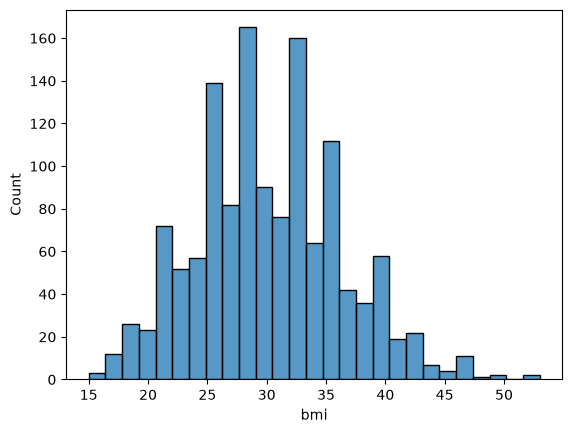

In [38]:
sns.histplot(df_cleaned['bmi'])

In [39]:
df_cleaned['bmi_category'] = pd.cut(
    df_cleaned['bmi'], bins=[0, 18.5, 24.9, 29.9, float('inf')], labels=['UnderWeight', 'Normal', 'OverWeight', 'Obesity']
)

In [40]:
df_cleaned

,age,isFemale,bmi,children,isSmoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,0,1,OverWeight
1,18,0,33,1,0,1725,0,0,1,0,Obesity
2,28,0,33,3,0,4449,0,0,1,0,Obesity
3,33,0,22,0,0,21984,0,1,0,0,Normal
4,32,0,28,0,0,3866,0,1,0,0,OverWeight
...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,0,1,0,0,Obesity
1334,18,1,31,0,0,2205,1,0,0,0,Obesity
1335,18,1,36,0,0,1629,0,0,1,0,Obesity
1336,21,1,25,0,0,2007,0,0,0,1,OverWeight


In [41]:
# One hot encoding for BMI Category

df_cleaned = pd.get_dummies(df_cleaned,columns = ['bmi_category'])

In [42]:
df_cleaned.head()

,age,isFemale,bmi,children,isSmoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_UnderWeight,bmi_category_Normal,bmi_category_OverWeight,bmi_category_Obesity
0,19,1,27,0,1,16884,0,0,0,1,False,False,True,False
1,18,0,33,1,0,1725,0,0,1,0,False,False,False,True
2,28,0,33,3,0,4449,0,0,1,0,False,False,False,True
3,33,0,22,0,0,21984,0,1,0,0,False,True,False,False
4,32,0,28,0,0,3866,0,1,0,0,False,False,True,False


In [43]:
df_cleaned.astype(int)

,age,isFemale,bmi,children,isSmoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_UnderWeight,bmi_category_Normal,bmi_category_OverWeight,bmi_category_Obesity
0,19,1,27,0,1,16884,0,0,0,1,0,0,1,0
1,18,0,33,1,0,1725,0,0,1,0,0,0,0,1
2,28,0,33,3,0,4449,0,0,1,0,0,0,0,1
3,33,0,22,0,0,21984,0,1,0,0,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,0,1,0,0,0,0,0,1
1334,18,1,31,0,0,2205,1,0,0,0,0,0,0,1
1335,18,1,36,0,0,1629,0,0,1,0,0,0,0,1
1336,21,1,25,0,0,2007,0,0,0,1,0,0,1,0


In [44]:
df_cleaned.head()

,age,isFemale,bmi,children,isSmoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_UnderWeight,bmi_category_Normal,bmi_category_OverWeight,bmi_category_Obesity
0,19,1,27,0,1,16884,0,0,0,1,False,False,True,False
1,18,0,33,1,0,1725,0,0,1,0,False,False,False,True
2,28,0,33,3,0,4449,0,0,1,0,False,False,False,True
3,33,0,22,0,0,21984,0,1,0,0,False,True,False,False
4,32,0,28,0,0,3866,0,1,0,0,False,False,True,False


In [45]:
df_cleaned.tail()

,age,isFemale,bmi,children,isSmoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_UnderWeight,bmi_category_Normal,bmi_category_OverWeight,bmi_category_Obesity
1333,50,0,30,3,0,10600,0,1,0,0,False,False,False,True
1334,18,1,31,0,0,2205,1,0,0,0,False,False,False,True
1335,18,1,36,0,0,1629,0,0,1,0,False,False,False,True
1336,21,1,25,0,0,2007,0,0,0,1,False,False,True,False
1337,61,1,29,0,1,29141,0,1,0,0,False,False,True,False


In [46]:
# Feature Scaling

df_cleaned.columns

Index(['age', 'isFemale', 'bmi', 'children', 'isSmoker', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_category_UnderWeight', 'bmi_category_Normal',
       'bmi_category_OverWeight', 'bmi_category_Obesity'],
      dtype='str')

In [47]:
from sklearn.preprocessing import StandardScaler
cols = ['age', 'bmi', 'children']
scaler = StandardScaler()

df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])

In [48]:
df_cleaned.head()

,age,isFemale,bmi,children,isSmoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_UnderWeight,bmi_category_Normal,bmi_category_OverWeight,bmi_category_Obesity
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,0,1,False,False,True,False
1,-1.511647,0,0.462463,-0.079442,0,1725,0,0,1,0,False,False,False,True
2,-0.799350,0,0.462463,1.580143,0,4449,0,0,1,0,False,False,False,True
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,1,0,0,False,True,False,False
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,1,0,0,False,False,True,False


In [49]:
# Feature Extraction / Selection
# Pearson Correlation

from scipy.stats import pearsonr

selected_features = ['age', 'isFemale', 'bmi', 'children', 'isSmoker', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_category_UnderWeight', 'bmi_category_Normal',
       'bmi_category_OverWeight', 'bmi_category_Obesity']

correlations = {feature: pearsonr(df_cleaned[feature], df_cleaned['charges'])[0] for feature in selected_features}
correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])
correlation_df.sort_values(by='Pearson Correlation', ascending=False)

,Feature,Pearson Correlation
5,charges,1.000000
4,isSmoker,0.787234
0,age,0.298309
13,bmi_category_Obesity,0.200348
2,bmi,0.196236
8,region_southeast,0.073577
3,children,0.067390
6,region_northeast,0.005946
7,region_northwest,-0.038695
9,region_southwest,-0.043637


In [53]:
# Traditional Person Correlation without scikit learn

import math
import pandas as pd

selected_features = ['age', 'isFemale', 'bmi', 'children', 'isSmoker', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_category_UnderWeight', 'bmi_category_Normal',
       'bmi_category_OverWeight', 'bmi_category_Obesity']

target = df_cleaned['charges']

def pearson_correlation(x,y):
    n = len(x)
    
    mean_x = sum(x)/n
    mean_y = sum(y)/n
    
    dev_x = [xi - mean_x for xi in x]
    dev_y = [yi - mean_y for yi in y]
    
    covariance = sum(
        dx * dy
        for dx,dy in zip(dev_x, dev_y)
    ) / (n - 1)
    
    variance_x = sum(
        dx ** 2 
        for dx in dev_x
    ) / (n-1)
    
    variance_y = sum(
        dy ** 2 
        for dy in dev_y
    ) / (n-1)
    
    std_x = math.sqrt(variance_x)
    std_y = math.sqrt(variance_y)
    
    r = covariance / (std_x * std_y)
    
    return r

correlations = {}

for feature in selected_features:
    x = df_cleaned[feature].tolist()
    y = target.tolist()
    
    correlations[feature] = pearson_correlation(x, y)
    
correlation_df = pd.DataFrame(
    list(correlations.items()),
    columns=[
        'Feature',
        'Pearson Correlation'
    ]
)

correlation_df = correlation_df.sort_values(
    by='Pearson Correlation',
    ascending=False
).reset_index(drop=True)

print(correlation_df)

                     Feature  Pearson Correlation
0                    charges             1.000000
1                   isSmoker             0.787234
2                        age             0.298309
3       bmi_category_Obesity             0.200348
4                        bmi             0.196236
5           region_southeast             0.073577
6                   children             0.067390
7           region_northeast             0.005946
8           region_northwest            -0.038695
9           region_southwest            -0.043637
10  bmi_category_UnderWeight            -0.050599
11                  isFemale            -0.058046
12       bmi_category_Normal            -0.104042
13   bmi_category_OverWeight            -0.120601


In [55]:
correlation_df['Absolute Correlation'] = (
    correlation_df['Pearson Correlation'].abs()
)

correlation_df = correlation_df.sort_values(
    by='Absolute Correlation',
    ascending=False
)

print(correlation_df)

                     Feature  Pearson Correlation  Absolute Correlation
0                    charges             1.000000              1.000000
1                   isSmoker             0.787234              0.787234
2                        age             0.298309              0.298309
3       bmi_category_Obesity             0.200348              0.200348
4                        bmi             0.196236              0.196236
13   bmi_category_OverWeight            -0.120601              0.120601
12       bmi_category_Normal            -0.104042              0.104042
5           region_southeast             0.073577              0.073577
6                   children             0.067390              0.067390
11                  isFemale            -0.058046              0.058046
10  bmi_category_UnderWeight            -0.050599              0.050599
9           region_southwest            -0.043637              0.043637
8           region_northwest            -0.038695              0

In [95]:
# Applying Chi-Square Test
from scipy.stats import chi2_contingency
import pandas as pd

categorical_features = ['isFemale', 'isSmoker',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_category_UnderWeight', 'bmi_category_Normal',
       'bmi_category_OverWeight', 'bmi_category_Obesity']

alpha = 0.05

# Creating Bins for charges
df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'], q=4, labels=False)
chi2_results = {}

# Loop for chi2_contingency

for col in categorical_features:
    contingency_table = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency_table)
    decision = 'Reject Null(Keep Feature)' if p_val < alpha else 'Accept Null(Drop Feature)'
    chi2_results[col] = {
        'chi2_statistics' : chi2_stat,
        'p_value' : p_val,
        'Decision' : decision
    }


chi2_df  = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistics,p_value,Decision
isSmoker,848.219178,0.0,Reject Null(Keep Feature)
region_southeast,15.998167,0.001135,Reject Null(Keep Feature)
isFemale,10.258784,0.01649,Reject Null(Keep Feature)
bmi_category_Obesity,8.515711,0.036473,Reject Null(Keep Feature)
region_northeast,6.438442,0.092122,Accept Null(Drop Feature)
region_southwest,5.091893,0.165191,Accept Null(Drop Feature)
bmi_category_OverWeight,4.25149,0.235557,Accept Null(Drop Feature)
bmi_category_Normal,3.708088,0.29476,Accept Null(Drop Feature)
bmi_category_UnderWeight,3.37403,0.337471,Accept Null(Drop Feature)
region_northwest,1.13424,0.768815,Accept Null(Drop Feature)


In [96]:
final_df = df_cleaned[['age', 'isFemale', 'bmi', 'children', 'isSmoker', 'charges', 'region_southeast', 'bmi_category_Obesity']]

In [97]:
final_df

,age,isFemale,bmi,children,isSmoker,charges,region_southeast,bmi_category_Obesity
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,False
1,-1.511647,0,0.462463,-0.079442,0,1725,1,True
2,-0.799350,0,0.462463,1.580143,0,4449,1,True
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,False
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,False
...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,0,True
1334,-1.511647,1,0.135659,-0.909234,0,2205,0,True
1335,-1.511647,1,0.952670,-0.909234,0,1629,1,True
1336,-1.297958,1,-0.844753,-0.909234,0,2007,0,False


In [98]:
final_df['bmi_category_Obesity'] = (
    final_df['bmi_category_Obesity'].astype(int)
)

In [100]:
final_df.head()

,age,isFemale,bmi,children,isSmoker,charges,region_southeast,bmi_category_Obesity
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0
1,-1.511647,0,0.462463,-0.079442,0,1725,1,1
2,-0.799350,0,0.462463,1.580143,0,4449,1,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,0
